# Automatic Dysarthria Detection and Severity Classification

This Colab-ready notebook implements an end-to-end pipeline for:
1. **Dataset download** from Kaggle (TORGO + UA Speech)
2. Data preparation
3. MFCC + SVM baseline
4. wav2vec2 fine-tuning (binary + severity)
5. Cross-dataset evaluation
6. Visualizations & structured report

> Designed for Google Colab T4 GPU. Run cells top-to-bottom.

## 0) Install dependencies

In [ ]:
# ── Run this cell ONCE per fresh Colab runtime ──────────────────────────────
# Compatible with Colab's Python 3.12 environment (2024-2025 images).
import subprocess, sys

def pip(*args):
    """Install packages and print output on failure."""
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--no-warn-script-location", *args]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("STDOUT:", result.stdout[-3000:])
        print("STDERR:", result.stderr[-3000:])
        raise RuntimeError(f"pip failed for: {args}")

# ── Step 1: Kaggle CLI ───────────────────────────────────────────────────────
pip("kaggle")

# ── Step 2: Core audio / ML stack ───────────────────────────────────────────
# Do NOT pin pandas here — Colab 3.12 ships pandas 2.x already; re-pinning
# to 2.2.2 can break against newer numpy/scipy wheels baked into the image.
pip(
    "librosa>=0.10.1",
    "soundfile>=0.12.1",
    "scikit-learn>=1.3.0",
    "imbalanced-learn>=0.11.0",
    "seaborn>=0.13.0",
    "tqdm>=4.65.0",
)

# ── Step 3: HuggingFace stack (pick a mutually-compatible set) ───────────────
# transformers 4.40+ has Python 3.12 wheels and stable wav2vec2 support.
pip(
    "transformers>=4.40.0,<4.42.0",
    "tokenizers>=0.19.0,<0.20.0",
    "huggingface_hub>=0.23.0,<0.24.0",
    "datasets>=2.19.0,<2.21.0",
    "accelerate>=0.29.0,<0.31.0",
    "safetensors>=0.4.3",
)

print("✅ All packages installed successfully.")


✅ All packages installed successfully.


## 1) Kaggle Authentication

**Option A – automatic (recommended):** Upload your `kaggle.json` below.  
**Option B – manual:** Paste your username and key in the variables below.  

Get your API token from: https://www.kaggle.com/settings → Account → API → *Create New Token*

In [ ]:
import os, json
from pathlib import Path

# ── Option A: upload kaggle.json (preferred) ─────────────────────────────────
USE_UPLOAD = False   # ← set False to use Option B

if USE_UPLOAD:
    from google.colab import files
    print("Upload your kaggle.json now (from Kaggle → Settings → API → Create New Token):")
    uploaded = files.upload()          # triggers file picker
    kaggle_json = list(uploaded.values())[0]
    creds = json.loads(kaggle_json)
else:
    # ── Option B: hard-code credentials (less secure) ────────────────────────
    creds = {
        "username": "username",   # ← replace
        "key":      "key",    # ← replace
    }

# Write credentials to the standard location Kaggle CLI expects
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
kaggle_path = kaggle_dir / "kaggle.json"
kaggle_path.write_text(json.dumps(creds))
kaggle_path.chmod(0o600)
print(f"✅ Kaggle credentials saved to {kaggle_path}")

✅ Kaggle credentials saved to /root/.kaggle/kaggle.json


## 2) Download Datasets from Kaggle

Downloads to `/content/datasets/` and extracts in-place.  
⏱ TORGO ≈ 1–2 min | UA Speech ≈ 3–5 min on Colab (depending on file size).

In [ ]:
import subprocess, os
from pathlib import Path

DATASET_ROOT = Path("/content/datasets")
DATASET_ROOT.mkdir(parents=True, exist_ok=True)

TORGO_SLUG  = "pranaykoppula/torgo-audio"
UA_SLUG     = "aryashah2k/noise-reduced-uaspeech-dysarthria-dataset"

def kaggle_download(slug: str, dest: Path) -> None:
    dest.mkdir(parents=True, exist_ok=True)
    dest_str = str(dest)
    slug_dir = dest / slug.split("/")[-1]
    if slug_dir.exists() and any(slug_dir.rglob("*.wav")):
        print(f"  [skip] {slug} already extracted at {slug_dir}")
        return
    print(f"  Downloading {slug} …")
    subprocess.check_call(
        ["kaggle", "datasets", "download", "-d", slug, "-p", dest_str, "--unzip"],
        env={**os.environ}
    )
    print(f"  ✅ Done → {dest_str}")

print("Downloading TORGO …")
kaggle_download(TORGO_SLUG, DATASET_ROOT)

print("Downloading UA Speech …")
kaggle_download(UA_SLUG, DATASET_ROOT)

# ── Discover the actual extracted folder names ────────────────────────────────
def find_wav_root(base: Path, keywords: tuple) -> str:
    best, best_n = None, 0
    for d in sorted(base.rglob("*")):
        if not d.is_dir():
            continue
        if any(k in d.name.lower().replace("-", "_") for k in keywords):
            n = sum(1 for _ in d.rglob("*.wav"))
            if n > best_n:
                best, best_n = d, n
    if best is None or best_n == 0:
        # fallback: the root itself has wavs
        if any(base.rglob("*.wav")):
            return str(base)
        raise RuntimeError(f"No .wav files found under {base} for keywords {keywords}")
    return str(best)

TORGO_ROOT = find_wav_root(DATASET_ROOT, ("torgo",))
UA_ROOT    = find_wav_root(DATASET_ROOT, ("uaspeech", "ua_speech", "noisereduced"))

torgo_n = sum(1 for _ in Path(TORGO_ROOT).rglob("*.wav"))
ua_n    = sum(1 for _ in Path(UA_ROOT).rglob("*.wav"))
print(f"\nTORGO  root : {TORGO_ROOT}  ({torgo_n} wav files)")
print(f"UA     root : {UA_ROOT}  ({ua_n} wav files)")

  ✅ Done → /content/datasets
  ✅ Done → /content/datasets

TORGO  root : /content/datasets  (160925 wav files)
UA     root : /content/datasets/noisereduced-uaspeech  (73675 wav files)


## 0b) Repair broken `transformers` (run only if you see an `is_tf_tensor` ImportError)

Set `REPAIR_TRANSFORMERS = True`, run, let the runtime restart, then set it back to `False`.

In [ ]:
REPAIR_TRANSFORMERS = False
if REPAIR_TRANSFORMERS:
    import subprocess, sys
    # Remove all traces of the broken install
    for pkg in ("transformers", "tokenizers", "accelerate", "huggingface-hub", "huggingface_hub"):
        for _ in range(4):
            subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", pkg],
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    # Reinstall with Python-3.12-compatible, mutually-consistent versions
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
                           "transformers>=4.40.0,<4.42.0",
                           "tokenizers>=0.19.0,<0.20.0",
                           "huggingface_hub>=0.23.0,<0.24.0",
                           "accelerate>=0.29.0,<0.31.0",
                           "safetensors>=0.4.3"])
    # Verify in a clean subprocess (avoids stale sys.modules in this kernel)
    subprocess.check_call([sys.executable, "-c",
        "from transformers import Wav2Vec2ForSequenceClassification; "
        "import transformers; print('transformers OK:', transformers.__version__)"])
    print("Repair done.\nRuntime → Restart session, then set REPAIR_TRANSFORMERS = False and re-run.")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is not None and ip.kernel is not None:
            ip.kernel.do_shutdown(restart=True)
    except Exception:
        pass


## 3) Imports & Global Config

In [ ]:
import os, re, json, math, wave, random, warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from tqdm.auto import tqdm
import librosa
import soundfile as sf

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoFeatureExtractor, Wav2Vec2ForSequenceClassification,
                          get_linear_schedule_with_warmup)

# ── Sanity-check transformers install ────────────────────────────────────────
# transformers 4.35 used feature_extraction_sequence_utils; 4.40+ removed it.
# We just verify the classes we actually need are importable.
try:
    from transformers import Wav2Vec2ForSequenceClassification as _w2v_check  # noqa
    import transformers as _tr
    print(f"transformers {_tr.__version__} ✅")
except ImportError as e:
    raise ImportError(
        f"transformers import failed: {e}\n"
        "Set REPAIR_TRANSFORMERS=True in the Repair cell, run it, restart runtime, "
        "then set it back to False.") from e

# ── GradScaler: torch 2.x moved it to torch.amp ──────────────────────────────
import torch
_torch_major = int(torch.__version__.split(".")[0])
if _torch_major >= 2:
    from torch.amp import GradScaler as _GradScaler
    def make_grad_scaler(enabled=True):
        return _GradScaler("cuda", enabled=enabled)
else:
    from torch.cuda.amp import GradScaler as _GradScaler
    def make_grad_scaler(enabled=True):
        return _GradScaler(enabled=enabled)

warnings.filterwarnings("ignore")

SEED          = 42
TARGET_SR     = 16_000
MAX_AUDIO_SEC = 5.0
MAX_AUDIO_LEN = int(TARGET_SR * MAX_AUDIO_SEC)
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


transformers 4.41.2 ✅
Device : cuda
PyTorch: 2.10.0+cu128


## 4) Configuration

In [ ]:
# These paths come from the Kaggle download cell above.
# If you skipped that cell and already have the data, set them manually.
try:
    _torgo = TORGO_ROOT
    _ua    = UA_ROOT
except NameError:
    _torgo = "/content/datasets/torgo-audio"
    _ua    = "/content/datasets/noise-reduced-uaspeech-dysarthria-dataset"

CONFIG = {
    "torgo_root": _torgo,
    "ua_root":    _ua,
    "metadata_csv": None,
    "output_dir":   "/content/dysarthria_outputs",
    "wav2vec_checkpoint": "facebook/wav2vec2-base",
    "batch_size":  8,
    "num_workers": 0,
    "use_amp":     True,
    "gradient_accumulation_steps": 1,
    "epochs_binary":   3,
    "epochs_severity": 3,
    "lr_base":         2e-5,
    "lr_ref_batch_size": 4,
    "auto_scale_lr_with_batch": True,
    "weight_decay":  0.01,
    "warmup_ratio":  0.1,
    "freeze_feature_encoder": True,
    "freeze_encoder_layers":  6,
    "max_samples_per_dataset": 12_000,
    # UA Speech severity: 0=very_low, 1=low, 2=medium, 3=high
    "ua_speaker_severity_map": {
        "M01": 0, "M04": 0, "M05": 0, "F02": 0,
        "M07": 1, "M08": 1, "M09": 1, "F03": 1,
        "M10": 2, "M11": 2, "M12": 2, "F04": 2,
        "M14": 3, "M16": 3, "F05": 3,
    },
    "severity_expected_num_classes": 4,
    "severity_split_max_tries":      40,
    "severity_allow_collapse_4_to_3": True,
    "enable_interpretability": False,
    "perm_n_repeats":  1,
    "perm_max_samples": 1_500,
    "perm_n_jobs": -1,
}

if CONFIG.get("auto_scale_lr_with_batch", True):
    CONFIG["lr"] = float(CONFIG["lr_base"]) * (CONFIG["batch_size"] / CONFIG["lr_ref_batch_size"])
else:
    CONFIG["lr"] = float(CONFIG.get("lr", CONFIG["lr_base"]))

Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
print(f"Output dir  : {CONFIG['output_dir']}")
print(f"TORGO root  : {CONFIG['torgo_root']}")
print(f"UA root     : {CONFIG['ua_root']}")
print(f"LR          : {CONFIG['lr']:.2e}  |  batch={CONFIG['batch_size']}  |  device={DEVICE}")

Output dir  : /content/dysarthria_outputs
TORGO root  : /content/datasets
UA root     : /content/datasets/noisereduced-uaspeech
LR          : 4.00e-05  |  batch=8  |  device=cuda


## 5) Utility Functions

In [ ]:
SEVERITY_KEYWORDS = {"very_low": 0, "low": 1, "medium": 2, "high": 3}

def normalize_audio(x: np.ndarray) -> np.ndarray:
    return x / (np.max(np.abs(x)) + 1e-9)

def _load_wave_stdlib(path):
    with wave.open(path, "rb") as wf:
        sr, n_ch, sw = wf.getframerate(), wf.getnchannels(), wf.getsampwidth()
        raw = wf.readframes(wf.getnframes())
    dtypes = {1: np.uint8, 2: np.int16, 4: np.int32}
    if sw not in dtypes:
        raise ValueError(f"Unsupported sample width {sw}")
    audio = np.frombuffer(raw, dtype=dtypes[sw]).astype(np.float32)
    if sw == 1: audio = (audio - 128.0) / 128.0
    elif sw == 2: audio /= 32768.0
    else: audio /= 2_147_483_648.0
    if n_ch > 1: audio = audio.reshape(-1, n_ch).mean(1)
    return audio, sr

def load_audio_mono_16k(path: str, target_sr: int = TARGET_SR) -> np.ndarray:
    path = str(path)
    sz = Path(path).stat().st_size
    if sz < 128:
        raise ValueError(f"File too small ({sz} B): {path}")
    audio = sr = None
    for loader in [
        lambda p: sf.read(p),
        lambda p: _load_wave_stdlib(p),
        lambda p: librosa.load(p, sr=None, mono=True),
    ]:
        try:
            result = loader(path)
            audio, sr = result
            if isinstance(audio, np.ndarray) and audio.ndim > 1:
                audio = np.mean(audio, axis=1)
            audio = audio.astype(np.float32)
            break
        except Exception:
            pass
    if audio is None:
        raise RuntimeError(f"Could not decode: {path}")
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=int(sr), target_sr=target_sr)
    audio = normalize_audio(audio.astype(np.float32))
    if len(audio) >= MAX_AUDIO_LEN:
        audio = audio[:MAX_AUDIO_LEN]
    else:
        audio = np.pad(audio, (0, MAX_AUDIO_LEN - len(audio)))
    return audio

def metric_bundle(y_true, y_pred, average="binary"):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=average, zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

def print_metrics_table(name, metrics):
    print(f"\n{name}"); print("-" * len(name))
    for k, v in metrics.items(): print(f"{k:>10}: {v:.4f}")

def infer_speaker_id_from_path(path):
    p = Path(path)
    for token in reversed(p.parts):
        if re.fullmatch(r"(?:C?[FM]\d{2}|[FM]C\d{2})", token):
            return token
    joined = "_".join(p.parts)
    m = re.search(r"(?:^|_)([FM]C?\d{2}|C[FM]\d{2})(?:S\d{2})?(?:_|$)", joined)
    return m.group(1) if m else "unknown"

def infer_binary_label_from_path(path):
    p = Path(path)
    parts_l = [x.lower() for x in p.parts]
    if any(t in parts_l for t in ["f_con", "m_con", "noisereduced-uaspeech-control"]): return 0
    if any(t in parts_l for t in ["f_dys", "m_dys", "noisereduced-uaspeech"]): return 1
    speaker = infer_speaker_id_from_path(path).upper()
    if re.fullmatch(r"(?:CM|CF)\d{2}", speaker): return 0
    if re.fullmatch(r"(?:M|F)\d{2}", speaker):   return 1
    if re.fullmatch(r"(?:MC|FC)\d{2}", speaker):  return 0
    full_l = "/".join(parts_l)
    if any(k in full_l for k in ["control", "healthy", "non_dys"]): return 0
    return 1

def infer_severity_from_path(path, speaker_id=None, dataset_name=None):
    p_l = path.lower()
    for kw, val in SEVERITY_KEYWORDS.items():
        if kw in p_l: return val
    if dataset_name == "UA":
        sid = (speaker_id or infer_speaker_id_from_path(path)).replace("C", "")
        return int(CONFIG["ua_speaker_severity_map"].get(sid, -1))
    return -1

def collect_audio_files(root):
    r = Path(root)
    return [str(p) for p in r.rglob("*.wav")] if r.exists() else []

def diagnose_dataset_paths(config):
    print("\nDataset path diagnostics")
    for name, key in [("TORGO", "torgo_root"), ("UA", "ua_root")]:
        root = Path(config[key])
        n = len(list(root.rglob("*.wav"))) if root.exists() else 0
        print(f"{name}: root={root}  exists={root.exists()}  wav_files={n}")

print("✅ Utility functions defined.")

✅ Utility functions defined.


## 6) Build Metadata DataFrame

In [ ]:
def build_metadata(config):
    if config["metadata_csv"] and Path(config["metadata_csv"]).exists():
        df = pd.read_csv(config["metadata_csv"])
        required = {"audio_path","dataset","binary_label","severity_label","speaker_id"}
        missing = required - set(df.columns)
        if missing: raise ValueError(f"metadata_csv missing columns: {missing}")
        return df.copy()
    rows = []
    for ds_name, root_key in [("TORGO","torgo_root"),("UA","ua_root")]:
        root = config[root_key]
        files = collect_audio_files(root)
        max_s = config.get("max_samples_per_dataset")
        if max_s and len(files) > int(max_s):
            rng = np.random.RandomState(SEED)
            files = rng.choice(files, size=int(max_s), replace=False).tolist()
        print(f"[metadata] {ds_name}: {len(files)} wav files at {root}")
        for fp in files:
            sid = infer_speaker_id_from_path(fp)
            rows.append({
                "audio_path":    fp,
                "dataset":       ds_name,
                "binary_label":  int(infer_binary_label_from_path(fp)),
                "severity_label":int(infer_severity_from_path(fp, sid, ds_name)),
                "speaker_id":    str(sid),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        diagnose_dataset_paths(config)
        raise RuntimeError(
            "No audio files found. Check CONFIG['torgo_root'] and CONFIG['ua_root'].")
    return df

meta_df = build_metadata(CONFIG)
print("\nShape:", meta_df.shape)
print(meta_df.head(3))
print("\nDataset counts:\n", meta_df["dataset"].value_counts())
print("\nBinary label counts:\n", meta_df["binary_label"].value_counts())
print("\nSeverity label counts (−1 = unknown):\n",
      meta_df["severity_label"].value_counts().sort_index())

[metadata] TORGO: 12000 wav files at /content/datasets
[metadata] UA: 12000 wav files at /content/datasets/noisereduced-uaspeech

Shape: (24000, 5)
                                          audio_path dataset  binary_label  \
0  /content/datasets/noisereduced-uaspeech/F02/F0...   TORGO             1   
1  /content/datasets/M_Dys/wav_arrayMic_M04S02/wa...   TORGO             1   
2  /content/datasets/noisereduced-uaspeech-contro...   TORGO             0   

   severity_label speaker_id  
0              -1        F02  
1              -1        M04  
2              -1       CF02  

Dataset counts:
 dataset
TORGO    12000
UA       12000
Name: count, dtype: int64

Binary label counts:
 binary_label
1    17968
0     6032
Name: count, dtype: int64

Severity label counts (−1 = unknown):
 severity_label
-1    12000
 0     2785
 1     3491
 2     3312
 3     2412
Name: count, dtype: int64


## 6b) Dataset Overview Visualizations

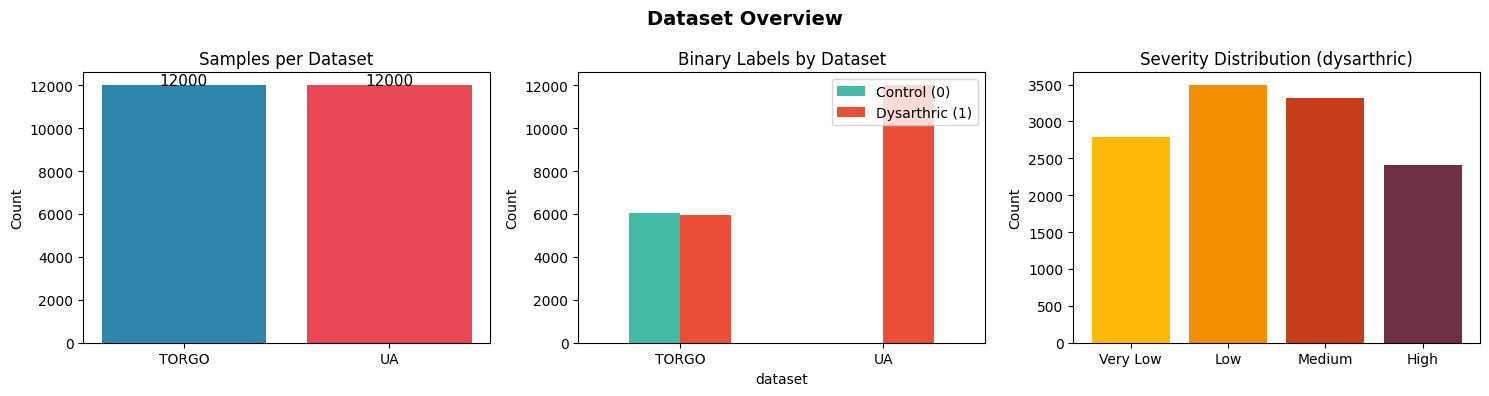

✅ Dataset overview saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

# Panel 1 – samples per dataset
ds_counts = meta_df["dataset"].value_counts()
axes[0].bar(ds_counts.index, ds_counts.values, color=["#2E86AB","#E84855"])
axes[0].set_title("Samples per Dataset")
axes[0].set_ylabel("Count")
for ax_i, (label, val) in enumerate(zip(ds_counts.index, ds_counts.values)):
    axes[0].text(ax_i, val + 20, str(val), ha="center", fontsize=11)

# Panel 2 – binary label distribution by dataset
cross = pd.crosstab(meta_df["dataset"], meta_df["binary_label"])
cross.columns = ["Control (0)", "Dysarthric (1)"]
cross.plot(kind="bar", ax=axes[1], color=["#44BBA4","#E94F37"], rot=0)
axes[1].set_title("Binary Labels by Dataset")
axes[1].set_ylabel("Count")
axes[1].legend(loc="upper right")

# Panel 3 – severity distribution (excluding -1)
sev_valid = meta_df[meta_df["severity_label"] >= 0]
sev_labels = {0:"Very Low", 1:"Low", 2:"Medium", 3:"High"}
sev_counts = sev_valid["severity_label"].value_counts().sort_index()
axes[2].bar([sev_labels.get(i, str(i)) for i in sev_counts.index],
             sev_counts.values, color=["#FFBA08","#F18F01","#C73E1D","#6D2E46"])
axes[2].set_title("Severity Distribution (dysarthric)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "dataset_overview.png", dpi=150)
plt.show()
print("✅ Dataset overview saved.")

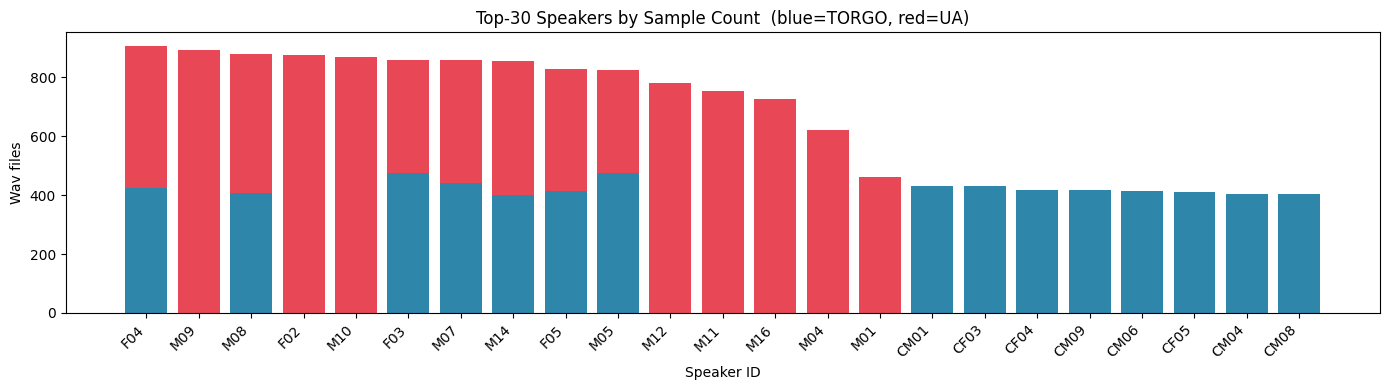

✅ Speaker distribution saved.


In [ ]:
# Samples per speaker (top 30 most frequent)
spk_counts = meta_df.groupby(["dataset","speaker_id"]).size().reset_index(name="n")
top30 = spk_counts.nlargest(30, "n")

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#2E86AB" if d == "TORGO" else "#E84855" for d in top30["dataset"]]
ax.bar(top30["speaker_id"], top30["n"], color=colors)
ax.set_title("Top-30 Speakers by Sample Count  (blue=TORGO, red=UA)")
ax.set_xlabel("Speaker ID")
ax.set_ylabel("Wav files")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "speaker_distribution.png", dpi=150)
plt.show()
print("✅ Speaker distribution saved.")

## 7) Train / Test Splits

In [ ]:
def speaker_stratified_split(df, test_ratio=0.2, seed=42):
    rng = np.random.RandomState(seed)
    tr_parts, te_parts = [], []
    for ds in df["dataset"].unique():
        sub = df[df["dataset"] == ds].copy()
        spks = sub["speaker_id"].unique().tolist(); rng.shuffle(spks)
        n_test = max(1, int(len(spks) * test_ratio))
        te_spks = set(spks[:n_test])
        tr_parts.append(sub[~sub["speaker_id"].isin(te_spks)])
        te_parts.append(sub[sub["speaker_id"].isin(te_spks)])
    return (pd.concat(tr_parts, ignore_index=True),
            pd.concat(te_parts, ignore_index=True))

def speaker_stratified_severity_split(df, test_ratio=0.2, seed=42):
    if len(df) < 30 or df["speaker_id"].nunique() < 6:
        return speaker_stratified_split(df, test_ratio, seed)
    n_splits = max(2, min(int(round(1/max(0.05,test_ratio))), 10))
    try:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        tr_i, te_i = next(sgkf.split(np.zeros(len(df)),
                                       df["severity_label"].values,
                                       df["speaker_id"].values))
        return df.iloc[tr_i].reset_index(drop=True), df.iloc[te_i].reset_index(drop=True)
    except ValueError:
        return speaker_stratified_split(df, test_ratio, seed)

def _cov(y, labels):
    vc = y.value_counts().to_dict()
    return {lb: int(vc.get(lb,0)) for lb in labels}

def _full_cov(tr, te, labels):
    return (all(v > 0 for v in _cov(tr["severity_label"], labels).values()) and
            all(v > 0 for v in _cov(te["severity_label"], labels).values()))

def collapse_4_to_3(df):
    out = df.copy()
    out["severity_label"] = out["severity_label"].map({0:0,1:0,2:1,3:2}).astype(int)
    return out

def find_best_severity_split(df, test_ratio, seed, expected_labels, max_tries):
    best, best_score = None, -1
    for k in range(max_tries):
        tr, te = speaker_stratified_severity_split(df, test_ratio, seed+k)
        score = (sum(int(v>0) for v in _cov(tr["severity_label"],expected_labels).values()) +
                 sum(int(v>0) for v in _cov(te["severity_label"],expected_labels).values()))
        if score > best_score:
            best_score, best = score, (tr, te)
        if _full_cov(tr, te, expected_labels):
            return tr, te, True
    return best[0], best[1], False

train_df, test_df = speaker_stratified_split(meta_df, seed=SEED)
print(f"Binary  → train: {len(train_df)}  test: {len(test_df)}")

severity_df = meta_df[(meta_df["severity_label"] >= 0) & (meta_df["binary_label"] == 1)].reset_index(drop=True)
exp_labels = list(range(CONFIG["severity_expected_num_classes"]))
sev_train_df, sev_test_df, ok4 = find_best_severity_split(
    severity_df, 0.2, SEED, exp_labels, CONFIG["severity_split_max_tries"])

severity_note = ""
if not ok4 and CONFIG["severity_allow_collapse_4_to_3"]:
    print("[severity] Falling back to 3-class severity.")
    severity_df = collapse_4_to_3(severity_df)
    exp_labels = [0,1,2]
    sev_train_df, sev_test_df, ok3 = find_best_severity_split(
        severity_df, 0.2, SEED, exp_labels, CONFIG["severity_split_max_tries"])
    severity_note = "Severity collapsed from 4 → 3 classes." if ok3 else                     "Severity split may not cover all classes; interpret cautiously."
elif not ok4:
    severity_note = "4-class severity split incomplete; interpret cautiously."

print(f"Severity → train: {len(sev_train_df)}  test: {len(sev_test_df)}")
if severity_note: print(f"[severity] {severity_note}")

Binary  → train: 19674  test: 4326
[severity] Falling back to 3-class severity.
Severity → train: 9576  test: 2424
[severity] Severity collapsed from 4 → 3 classes.


## 7b) MFCC Feature Visualization

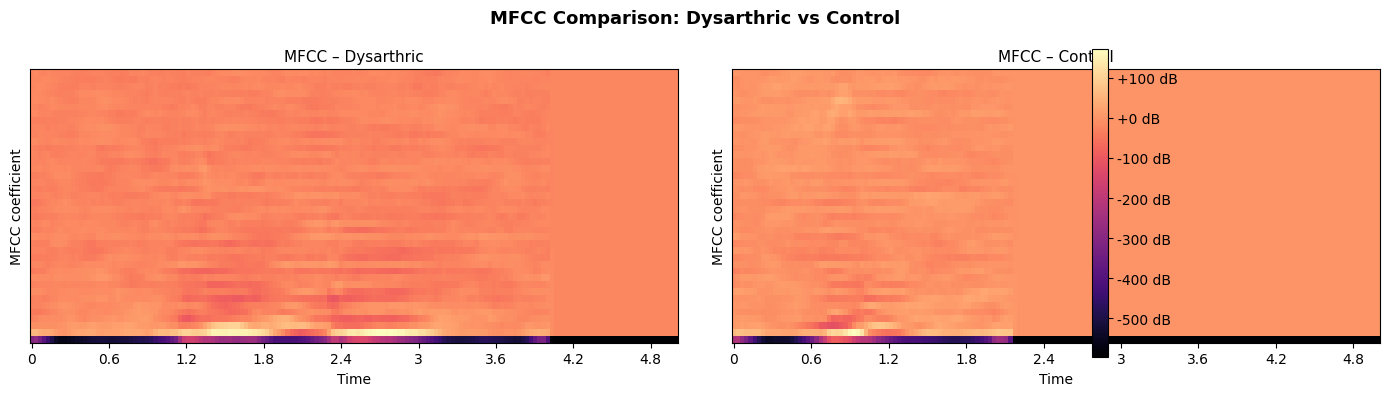

✅ MFCC comparison saved.


In [ ]:
# Visualise MFCCs from one dysarthric and one control sample
def plot_mfcc_example(path, label_name, ax, n_mfcc=40):
    y = load_audio_mono_16k(path)
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=n_mfcc)
    img = librosa.display.specshow(mfcc, sr=TARGET_SR, x_axis="time",
                                    ax=ax, cmap="magma")
    ax.set_title(f"MFCC – {label_name}", fontsize=11)
    ax.set_ylabel("MFCC coefficient")
    return img

try:
    import librosa.display
    dys_sample = train_df[train_df["binary_label"] == 1]["audio_path"].iloc[0]
    ctl_sample = train_df[train_df["binary_label"] == 0]["audio_path"].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle("MFCC Comparison: Dysarthric vs Control", fontsize=13, fontweight="bold")
    img1 = plot_mfcc_example(dys_sample, "Dysarthric", axes[0])
    img2 = plot_mfcc_example(ctl_sample, "Control",    axes[1])
    fig.colorbar(img2, ax=axes, format="%+2.0f dB")
    plt.tight_layout()
    plt.savefig(Path(CONFIG["output_dir"]) / "mfcc_comparison.png", dpi=150)
    plt.show()
    print("✅ MFCC comparison saved.")
except Exception as e:
    print(f"[mfcc viz] Skipped: {e}")

## 8) Baseline: MFCC + SVM

In [ ]:
def extract_mfcc_features(path, n_mfcc=40):
    y = load_audio_mono_16k(path)
    mfcc   = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=n_mfcc)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feat = np.concatenate([mfcc, delta, delta2], axis=0)
    return np.concatenate([feat.mean(1), feat.std(1), feat.min(1), feat.max(1)]).astype(np.float32)

def make_feature_matrix(df, desc="MFCC"):
    feats, keep = [], []
    n_fail, first_fail = 0, None
    for i, p in enumerate(tqdm(df["audio_path"].tolist(), desc=desc)):
        try:
            feats.append(extract_mfcc_features(p)); keep.append(i)
        except Exception as e:
            n_fail += 1
            if first_fail is None: first_fail = f"{p} ({e})"
    if not feats: raise RuntimeError(f"No MFCC extracted. First fail: {first_fail}")
    if n_fail: print(f"[mfcc] Skipped {n_fail}. Example: {first_fail}")
    return np.vstack(feats), df.iloc[keep].reset_index(drop=True)

X_train, train_df   = make_feature_matrix(train_df,     "MFCC train (binary)")
X_test,  test_df    = make_feature_matrix(test_df,      "MFCC test  (binary)")
y_train_bin = train_df["binary_label"].values
y_test_bin  = test_df["binary_label"].values

X_tr_sev, sev_train_df = make_feature_matrix(sev_train_df, "MFCC train (severity)")
X_te_sev, sev_test_df  = make_feature_matrix(sev_test_df,  "MFCC test  (severity)")
y_train_sev = sev_train_df["severity_label"].values
y_test_sev  = sev_test_df["severity_label"].values

ros = RandomOverSampler(random_state=SEED)
X_tr_bin_b, y_tr_bin_b = ros.fit_resample(X_train, y_train_bin)
X_tr_sev_b, y_tr_sev_b = ros.fit_resample(X_tr_sev, y_train_sev)

def make_svm(): return Pipeline([("sc", StandardScaler()),
                                  ("clf", SVC(kernel="rbf", C=5, gamma="scale", class_weight="balanced"))])

bin_svm = make_svm(); bin_svm.fit(X_tr_bin_b, y_tr_bin_b)
bin_pred_bl = bin_svm.predict(X_test)
bin_metrics_baseline = metric_bundle(y_test_bin, bin_pred_bl, "binary")
print_metrics_table("Baseline MFCC+SVM (Binary)", bin_metrics_baseline)
print("\nBinary report:\n", classification_report(y_test_bin, bin_pred_bl, digits=4))

sev_svm = make_svm(); sev_svm.fit(X_tr_sev_b, y_tr_sev_b)
sev_pred_bl = sev_svm.predict(X_te_sev)
sev_metrics_baseline = metric_bundle(y_test_sev, sev_pred_bl, "macro")
print_metrics_table("Baseline MFCC+SVM (Severity)", sev_metrics_baseline)
print("\nSeverity report:\n", classification_report(y_test_sev, sev_pred_bl, digits=4))

MFCC train (binary):   0%|          | 0/19674 [00:00<?, ?it/s]

MFCC test  (binary):   0%|          | 0/4326 [00:00<?, ?it/s]

MFCC train (severity):   0%|          | 0/9576 [00:00<?, ?it/s]

MFCC test  (severity):   0%|          | 0/2424 [00:00<?, ?it/s]


Baseline MFCC+SVM (Binary)
--------------------------
  accuracy: 0.9267
 precision: 0.9083
    recall: 0.9954
        f1: 0.9499

Binary report:
               precision    recall  f1-score   support

           0     0.9863    0.7685    0.8639      1309
           1     0.9083    0.9954    0.9499      3017

    accuracy                         0.9267      4326
   macro avg     0.9473    0.8819    0.9069      4326
weighted avg     0.9319    0.9267    0.9239      4326


Baseline MFCC+SVM (Severity)
----------------------------
  accuracy: 0.3593
 precision: 0.3048
    recall: 0.3580
        f1: 0.2701

Severity report:
               precision    recall  f1-score   support

           0     0.3782    0.8632    0.5260       826
           1     0.2205    0.0322    0.0562       870
           2     0.3155    0.1786    0.2281       728

    accuracy                         0.3593      2424
   macro avg     0.3048    0.3580    0.2701      2424
weighted avg     0.3028    0.3593    0.2679  

## 8b) Baseline Confusion Matrices

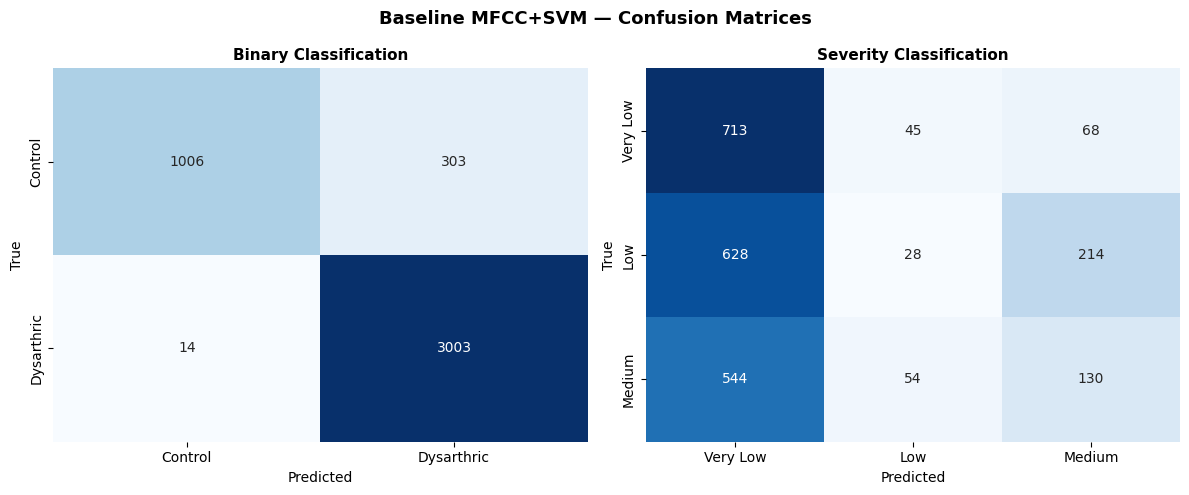

✅ Confusion matrices saved.


In [ ]:
def plot_cm(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels,
                yticklabels=labels, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontsize=11, fontweight="bold")

bin_labels = ["Control", "Dysarthric"]
sev_label_names = {0:"Very Low",1:"Low",2:"Medium",3:"High"}
sev_labels = [sev_label_names.get(i,str(i)) for i in sorted(set(y_test_sev))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Baseline MFCC+SVM — Confusion Matrices", fontsize=13, fontweight="bold")
plot_cm(y_test_bin, bin_pred_bl,  bin_labels,  "Binary Classification",   axes[0])
plot_cm(y_test_sev, sev_pred_bl,  sev_labels,  "Severity Classification", axes[1])
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "baseline_confusion_matrices.png", dpi=150)
plt.show()
print("✅ Confusion matrices saved.")

## 9) wav2vec2 — Dataset & DataLoaders

In [ ]:
class DysarthriaDataset(Dataset):
    def __init__(self, df, label_col):
        self.df = df.reset_index(drop=True)
        self.label_col = label_col
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        return {"input_values": load_audio_mono_16k(row["audio_path"]),
                "labels": int(row[self.label_col])}

@dataclass
class Collator:
    feature_extractor: AutoFeatureExtractor
    def __call__(self, features):
        inputs = [f["input_values"] for f in features]
        labels = torch.tensor([f["labels"] for f in features], dtype=torch.long)
        batch  = self.feature_extractor(inputs, sampling_rate=TARGET_SR,
                                         return_tensors="pt", padding=True)
        batch["labels"] = labels
        return batch

def make_loader(df, label_col, feat_ext, shuffle=True):
    ds = DysarthriaDataset(df, label_col)
    nw = CONFIG["num_workers"]
    kw = dict(dataset=ds, batch_size=CONFIG["batch_size"], shuffle=shuffle,
               num_workers=nw, pin_memory=(DEVICE=="cuda"), collate_fn=Collator(feat_ext))
    if nw > 0: kw["prefetch_factor"] = 2
    return DataLoader(**kw)

print("✅ DataLoader helpers defined.")

✅ DataLoader helpers defined.


## 10) wav2vec2 — Model Build & Training

In [ ]:
def build_wav2vec2(num_labels):
    model = Wav2Vec2ForSequenceClassification.from_pretrained(
        CONFIG["wav2vec_checkpoint"], num_labels=num_labels,
        problem_type="single_label_classification",
        attention_dropout=0.1, hidden_dropout=0.1, feat_proj_dropout=0.1)
    if CONFIG["freeze_feature_encoder"]:
        model.wav2vec2.feature_extractor._freeze_parameters()
    for i, layer in enumerate(model.wav2vec2.encoder.layers):
        if i < CONFIG["freeze_encoder_layers"]:
            for p in layer.parameters(): p.requires_grad = False
    return model

def class_weights(labels):
    classes, counts = np.unique(labels, return_counts=True)
    w = np.zeros(classes.max()+1, dtype=np.float32)
    total = counts.sum()
    for c, cnt in zip(classes, counts): w[c] = total / (len(classes)*cnt)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

def train_one_task(train_df, valid_df, label_col, num_labels, epochs, avg, run_name):
    feat_ext = AutoFeatureExtractor.from_pretrained(CONFIG["wav2vec_checkpoint"])
    model    = build_wav2vec2(num_labels).to(DEVICE)
    tr_loader = make_loader(train_df, label_col, feat_ext, shuffle=True)
    va_loader = make_loader(valid_df, label_col, feat_ext, shuffle=False)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    accum = max(1, CONFIG.get("gradient_accumulation_steps", 1))
    total_steps  = math.ceil(len(tr_loader) / accum) * epochs
    warmup_steps = int(total_steps * CONFIG["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    criterion = nn.CrossEntropyLoss(weight=class_weights(train_df[label_col].values))

    use_amp = CONFIG.get("use_amp", True) and DEVICE == "cuda"
    scaler  = make_grad_scaler(enabled=use_amp) if use_amp else None

    best_f1, best_state, history = -1., None, []
    for epoch in range(1, epochs + 1):

        # ── Training loop ────────────────────────────────────────────────────
        model.train(); tr_loss = 0.; optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(tqdm(tr_loader, desc=f"[{run_name}] Train {epoch}/{epochs}")):
            iv = batch["input_values"].to(DEVICE)
            am = batch.get("attention_mask"); am = am.to(DEVICE) if am is not None else None
            lb = batch["labels"].to(DEVICE)
            if use_amp:
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    logits = model(iv, attention_mask=am).logits
                loss = criterion(logits.float(), lb) / accum   # float32 for loss
                scaler.scale(loss).backward()
            else:
                logits = model(iv, attention_mask=am).logits
                loss = criterion(logits, lb) / accum
                loss.backward()
            tr_loss += loss.detach().item() * accum
            if (step + 1) % accum == 0 or (step + 1) == len(tr_loader):
                if use_amp:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
                    scaler.step(optimizer); scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
                    optimizer.step()
                scheduler.step(); optimizer.zero_grad(set_to_none=True)

        # ── Validation loop ──────────────────────────────────────────────────
        model.eval(); val_loss = 0.; y_true, y_pred = [], []
        with torch.no_grad():
            for batch in tqdm(va_loader, desc=f"[{run_name}] Valid {epoch}/{epochs}"):
                iv = batch["input_values"].to(DEVICE)
                am = batch.get("attention_mask"); am = am.to(DEVICE) if am is not None else None
                lb = batch["labels"].to(DEVICE)
                if use_amp:
                    with torch.amp.autocast("cuda", dtype=torch.float16):
                        out = model(iv, attention_mask=am)
                    logits_f32 = out.logits.float()   # cast BEFORE criterion
                else:
                    out = model(iv, attention_mask=am)
                    logits_f32 = out.logits.float()
                val_loss += criterion(logits_f32, lb).item()
                y_pred.extend(torch.argmax(logits_f32, -1).cpu().tolist())
                y_true.extend(lb.cpu().tolist())

        m = metric_bundle(y_true, y_pred, avg)
        history.append({"epoch": epoch,
                         "train_loss": tr_loss / max(1, len(tr_loader)),
                         "val_loss":   val_loss / max(1, len(va_loader)),
                         **m})
        print(f"[{run_name}] Ep {epoch} | "
              f"tr_loss={history[-1]['train_loss']:.4f} "
              f"val_loss={history[-1]['val_loss']:.4f} "
              f"acc={m['accuracy']:.4f} f1={m['f1']:.4f}")
        if m["f1"] > best_f1:
            best_f1 = m["f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state: model.load_state_dict(best_state)
    return model, {"history": history, "best_f1": best_f1}

print("✅ Model & training helpers defined.")

✅ Model & training helpers defined.


## 11) Train wav2vec2

In [ ]:
bin_model, bin_log = train_one_task(
    train_df, test_df, "binary_label", 2,
    CONFIG["epochs_binary"], "binary", "w2v_binary")

if len(severity_df) == 0:
    raise RuntimeError("No severity samples. Check ua_speaker_severity_map or provide metadata_csv.")

sev_num_labels = int(severity_df["severity_label"].max() + 1)
sev_model, sev_log = train_one_task(
    sev_train_df, sev_test_df, "severity_label", sev_num_labels,
    CONFIG["epochs_severity"], "macro", "w2v_severity")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[w2v_binary] Train 1/3:   0%|          | 0/2460 [00:00<?, ?it/s]

...

[w2v_severity] Valid 2/3:   0%|          | 0/303 [00:00<?, ?it/s]

[w2v_severity] Ep 2 | tr_loss=0.1012 val_loss=6.1023 acc=0.3127 f1=0.2402


[w2v_severity] Train 3/3:   0%|          | 0/1197 [00:00<?, ?it/s]

[w2v_severity] Valid 3/3:   0%|          | 0/303 [00:00<?, ?it/s]

[w2v_severity] Ep 3 | tr_loss=0.0354 val_loss=6.7471 acc=0.2760 f1=0.2142


## 11b) Training Curves

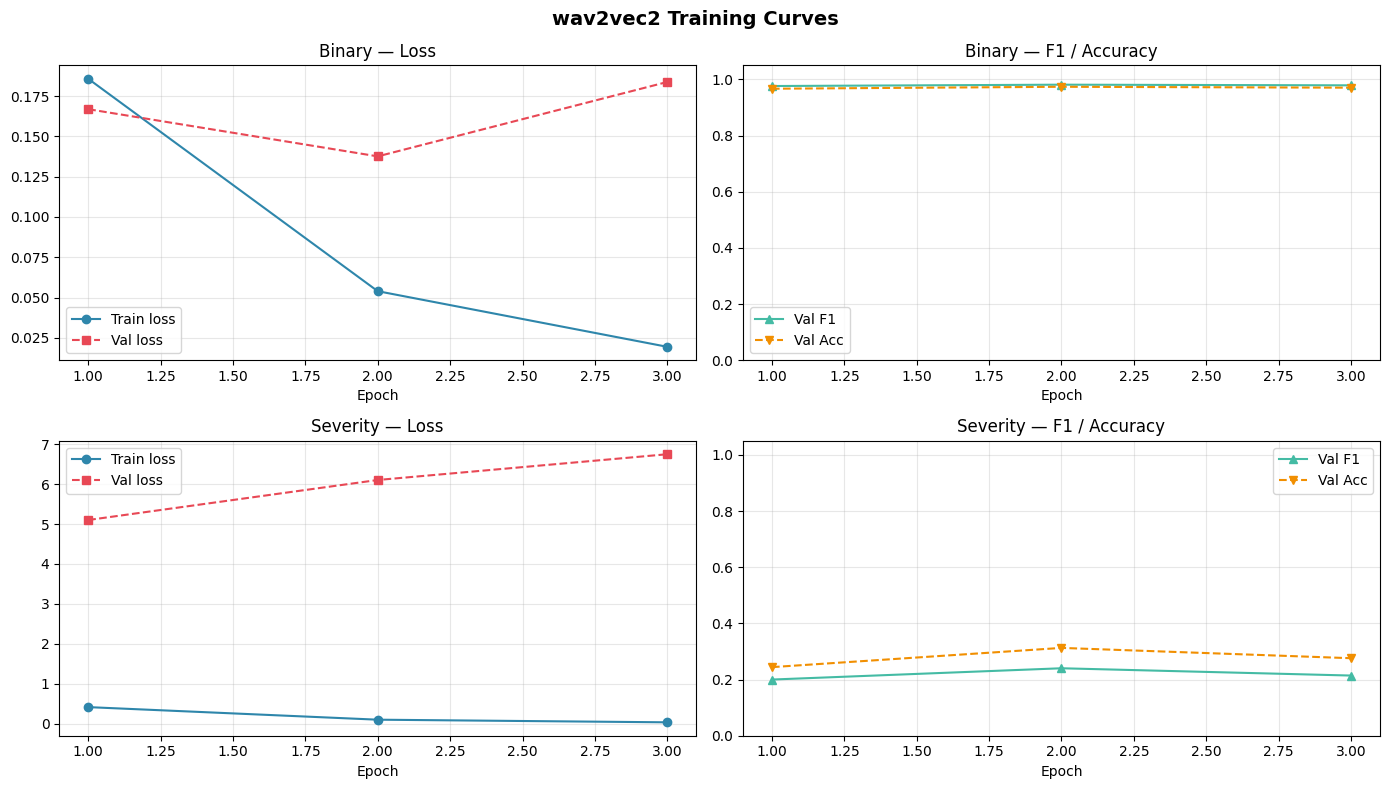

✅ Training curves saved.


In [ ]:
def plot_training_curves(log, title, avg_mode, ax_loss, ax_f1):
    hist = log["history"]
    epochs = [h["epoch"] for h in hist]
    ax_loss.plot(epochs, [h["train_loss"] for h in hist], "o-", label="Train loss", color="#2E86AB")
    ax_loss.plot(epochs, [h["val_loss"]   for h in hist], "s--",label="Val loss",   color="#E84855")
    ax_loss.set_title(f"{title} — Loss"); ax_loss.set_xlabel("Epoch"); ax_loss.legend(); ax_loss.grid(alpha=0.3)
    ax_f1.plot(epochs, [h["f1"] for h in hist], "^-", label="Val F1", color="#44BBA4")
    ax_f1.plot(epochs, [h["accuracy"] for h in hist], "v--",label="Val Acc",color="#F18F01")
    ax_f1.set_title(f"{title} — F1 / Accuracy"); ax_f1.set_xlabel("Epoch")
    ax_f1.set_ylim(0, 1.05); ax_f1.legend(); ax_f1.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("wav2vec2 Training Curves", fontsize=14, fontweight="bold")
plot_training_curves(bin_log, "Binary",   "binary", axes[0,0], axes[0,1])
plot_training_curves(sev_log, "Severity", "macro",  axes[1,0], axes[1,1])
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "training_curves.png", dpi=150)
plt.show()
print("✅ Training curves saved.")

## 12) Evaluate wav2vec2 on Held-Out Test

In [ ]:
def eval_wav2vec2(model, df, label_col, avg):
    feat_ext = AutoFeatureExtractor.from_pretrained(CONFIG["wav2vec_checkpoint"])
    loader   = make_loader(df, label_col, feat_ext, shuffle=False)
    model.eval(); y_true, y_pred = [], []
    use_amp = CONFIG.get("use_amp", True) and DEVICE == "cuda"
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Eval {label_col}"):
            iv = batch["input_values"].to(DEVICE)
            am = batch.get("attention_mask"); am = am.to(DEVICE) if am is not None else None
            lb = batch["labels"]
            if use_amp:
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    out = model(iv, attention_mask=am)
            else:
                out = model(iv, attention_mask=am)
            y_pred.extend(torch.argmax(out.logits.float(),-1).cpu().tolist())
            y_true.extend(lb.tolist())
    return {"metrics": metric_bundle(y_true, y_pred, avg), "y_true": y_true, "y_pred": y_pred}

bin_eval = eval_wav2vec2(bin_model, test_df,     "binary_label",   "binary")
sev_eval = eval_wav2vec2(sev_model, sev_test_df, "severity_label", "macro")

print_metrics_table("wav2vec2 (Binary)",   bin_eval["metrics"])
print("\nBinary report:\n",
      classification_report(bin_eval["y_true"], bin_eval["y_pred"], digits=4))

print_metrics_table("wav2vec2 (Severity)", sev_eval["metrics"])
print("\nSeverity report:\n",
      classification_report(sev_eval["y_true"], sev_eval["y_pred"], digits=4))

Eval binary_label:   0%|          | 0/541 [00:00<?, ?it/s]

Eval severity_label:   0%|          | 0/303 [00:00<?, ?it/s]


wav2vec2 (Binary)
-----------------
  accuracy: 0.9736
 precision: 0.9811
    recall: 0.9811
        f1: 0.9811

Binary report:
               precision    recall  f1-score   support

           0     0.9565    0.9565    0.9565      1309
           1     0.9811    0.9811    0.9811      3017

    accuracy                         0.9736      4326
   macro avg     0.9688    0.9688    0.9688      4326
weighted avg     0.9736    0.9736    0.9736      4326


wav2vec2 (Severity)
-------------------
  accuracy: 0.3127
 precision: 0.2127
    recall: 0.3122
        f1: 0.2402

Severity report:
               precision    recall  f1-score   support

           0     0.4192    0.7603    0.5404       826
           1     0.0621    0.0115    0.0194       870
           2     0.1569    0.1648    0.1608       728

    accuracy                         0.3127      2424
   macro avg     0.2127    0.3122    0.2402      2424
weighted avg     0.2123    0.3127    0.2394      2424



## 12b) wav2vec2 Confusion Matrices

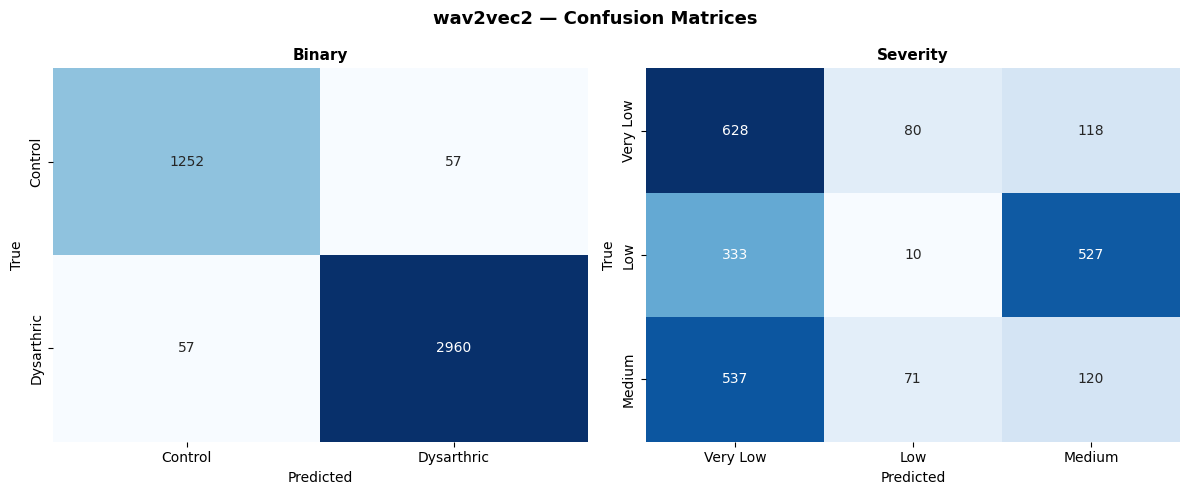

✅ wav2vec2 confusion matrices saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("wav2vec2 — Confusion Matrices", fontsize=13, fontweight="bold")
plot_cm(bin_eval["y_true"], bin_eval["y_pred"], bin_labels, "Binary",   axes[0])
plot_cm(sev_eval["y_true"], sev_eval["y_pred"], sev_labels, "Severity", axes[1])
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "wav2vec2_confusion_matrices.png", dpi=150)
plt.show()
print("✅ wav2vec2 confusion matrices saved.")

## 13) Cross-Dataset Evaluation

In [ ]:
CONFIG["torgo_root"] = "/content/datasets"
CONFIG["ua_root"]    = "/content/datasets/noisereduced-uaspeech"

# UA controls live here — we need to add them
UA_CONTROL_ROOT = "/content/datasets/noisereduced-uaspeech-control"
print("TORGO root:", CONFIG["torgo_root"])
print("UA    root:", CONFIG["ua_root"])
print("UA control:", UA_CONTROL_ROOT)

NameError: name 'CONFIG' is not defined

In [ ]:
def drop_bad_audio(df, desc="Verify"):
    keep = []
    for i, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try: load_audio_mono_16k(row["audio_path"]); keep.append(i)
        except: pass
    return df.loc[keep].reset_index(drop=True)

def cross_split(df, train_ds, test_ds):
    tr = df[df["dataset"] == train_ds].reset_index(drop=True)
    te = df[df["dataset"] == test_ds].reset_index(drop=True)
    if len(tr) == 0 or len(te) == 0:
        raise ValueError(f"Missing data: train={train_ds} test={test_ds}")
    return tr, te

def _has_multiple_classes(df, label_col):
    """Return True only if df has at least 2 distinct values in label_col."""
    return df[label_col].nunique() >= 2

NAN_METRICS = {"accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan}

def run_cross_baseline(df, train_ds, test_ds, label_col, avg):
    tr, te = cross_split(df, train_ds, test_ds)

    # Guard: both splits must have more than one class
    if not _has_multiple_classes(tr, label_col):
        print(f"[cross_baseline] Skipping {train_ds}->{test_ds} / {label_col}: "
              f"train set has only 1 class → {tr[label_col].unique()}")
        return {"metrics": NAN_METRICS}
    if not _has_multiple_classes(te, label_col):
        print(f"[cross_baseline] Skipping {train_ds}->{test_ds} / {label_col}: "
              f"test set has only 1 class → {te[label_col].unique()}")
        return {"metrics": NAN_METRICS}

    Xtr, tr2 = make_feature_matrix(tr, f"MFCC {train_ds}->{test_ds} train")
    Xte, te2 = make_feature_matrix(te, f"MFCC {train_ds}->{test_ds} test")
    ytr, yte = tr2[label_col].values, te2[label_col].values

    # Guard again after MFCC extraction (corrupt files may have been dropped)
    if np.unique(ytr).size <= 1:
        print(f"[cross_baseline] Skipping after MFCC drop: train has only 1 class.")
        return {"metrics": NAN_METRICS}

    Xtr_b, ytr_b = RandomOverSampler(random_state=SEED).fit_resample(Xtr, ytr)
    clf = make_svm(); clf.fit(Xtr_b, ytr_b)
    yp = clf.predict(Xte)
    return {"metrics": metric_bundle(yte, yp, avg), "y_true": yte, "y_pred": yp}

def run_cross_w2v(df, train_ds, test_ds, label_col, num_labels, avg, epochs, run_name):
    tr, te = cross_split(df, train_ds, test_ds)

    # Guard: both splits must have more than one class
    if not _has_multiple_classes(tr, label_col):
        print(f"[cross_w2v] Skipping {train_ds}->{test_ds} / {label_col}: "
              f"train set has only 1 class.")
        return {"metrics": NAN_METRICS}
    if not _has_multiple_classes(te, label_col):
        print(f"[cross_w2v] Skipping {train_ds}->{test_ds} / {label_col}: "
              f"test set has only 1 class.")
        return {"metrics": NAN_METRICS}

    tr = drop_bad_audio(tr, f"verify {train_ds}")
    te = drop_bad_audio(te, f"verify {test_ds}")
    if len(tr) == 0 or len(te) == 0:
        return {"metrics": NAN_METRICS}

    # Guard once more after dropping bad audio
    if not _has_multiple_classes(tr, label_col) or not _has_multiple_classes(te, label_col):
        print(f"[cross_w2v] Skipping after bad-audio drop: only 1 class remains.")
        return {"metrics": NAN_METRICS}

    model, _ = train_one_task(tr, te, label_col, num_labels, epochs, avg, run_name)
    return eval_wav2vec2(model, te, label_col, avg)

cross_results = {}
sev_meta = meta_df[(meta_df["severity_label"] >= 0) & (meta_df["binary_label"] == 1)].reset_index(drop=True)

for train_ds, test_ds in [("TORGO", "UA"), ("UA", "TORGO")]:
    key = f"{train_ds}_to_{test_ds}"
    cross_results[key] = {}

    cross_results[key]["baseline_binary"] = run_cross_baseline(
        meta_df, train_ds, test_ds, "binary_label", "binary")

    tr_sev = sev_meta[sev_meta["dataset"] == train_ds]
    te_sev = sev_meta[sev_meta["dataset"] == test_ds]
    if len(tr_sev) > 0 and len(te_sev) > 0:
        cross_results[key]["baseline_severity"] = run_cross_baseline(
            sev_meta, train_ds, test_ds, "severity_label", "macro")
    else:
        cross_results[key]["baseline_severity"] = {"metrics": NAN_METRICS}

    cross_results[key]["w2v_binary"] = run_cross_w2v(
        meta_df, train_ds, test_ds, "binary_label", 2, "binary",
        max(2, CONFIG["epochs_binary"] - 1), f"w2v_bin_{key}")

    if len(tr_sev) > 0 and len(te_sev) > 0:
        cross_results[key]["w2v_severity"] = run_cross_w2v(
            sev_meta, train_ds, test_ds, "severity_label", sev_num_labels, "macro",
            max(2, CONFIG["epochs_severity"] - 1), f"w2v_sev_{key}")
    else:
        cross_results[key]["w2v_severity"] = {"metrics": NAN_METRICS}

for k, v in cross_results.items():
    print(f"\n=== {k} ===")
    for mn, pack in v.items():
        print_metrics_table(mn, pack["metrics"])

[cross_baseline] Skipping TORGO->UA / binary_label: test set has only 1 class → [1]
[cross_w2v] Skipping TORGO->UA / binary_label: test set has only 1 class.
[cross_baseline] Skipping UA->TORGO / binary_label: train set has only 1 class → [1]
[cross_w2v] Skipping UA->TORGO / binary_label: train set has only 1 class.

=== TORGO_to_UA ===

baseline_binary
---------------
  accuracy: nan
 precision: nan
    recall: nan
        f1: nan

baseline_severity
-----------------
  accuracy: nan
 precision: nan
    recall: nan
        f1: nan

w2v_binary
----------
  accuracy: nan
 precision: nan
    recall: nan
        f1: nan

w2v_severity
------------
  accuracy: nan
 precision: nan
    recall: nan
        f1: nan

=== UA_to_TORGO ===

baseline_binary
---------------
  accuracy: nan
 precision: nan
    recall: nan
        f1: nan

baseline_severity
-----------------
  accuracy: nan
 precision: nan
    recall: nan
        f1: nan

w2v_binary
----------
  accuracy: nan
 precision: nan
    recall:

In [ ]:
from pathlib import Path

for ds_name, root_key in [("TORGO", "torgo_root"), ("UA", "ua_root")]:
    root = Path(CONFIG[root_key])
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name}  |  Root: {root}")
    print(f"{'='*60}")

    if root.exists():
        children = sorted(root.iterdir())
        print(f"\nTop-level children ({len(children)}):")
        for c in children[:20]:
            n_wav = sum(1 for _ in c.rglob("*.wav")) if c.is_dir() else 0
            print(f"  {'[DIR]' if c.is_dir() else '[FILE]'} {c.name}  ({n_wav} wavs)")

        print(f"\nLevel-2 sample (first 3 subdirs):")
        for c in children[:3]:
            if c.is_dir():
                for s in sorted(c.iterdir())[:5]:
                    n_wav = sum(1 for _ in s.rglob("*.wav")) if s.is_dir() else 0
                    print(f"    {c.name}/{s.name}  ({n_wav} wavs)")

        print(f"\nSample wav paths (first 8):")
        for w in list(root.rglob("*.wav"))[:8]:
            print(f"  {w.relative_to(root)}")
    else:
        print("  ❌ Root does not exist!")


Dataset: TORGO  |  Root: /content/datasets

Top-level children (6):
  [DIR] F_Con  (4678 wavs)
  [DIR] F_Dys  (2391 wavs)
  [DIR] M_Con  (6778 wavs)
  [DIR] M_Dys  (3788 wavs)
  [DIR] noisereduced-uaspeech  (73675 wavs)
  [DIR] noisereduced-uaspeech-control  (69615 wavs)

Level-2 sample (first 3 subdirs):
    F_Con/wav_arrayMic_FC01S01  (256 wavs)
    F_Con/wav_arrayMic_FC02S02  (269 wavs)
    F_Con/wav_arrayMic_FC02S03  (992 wavs)
    F_Con/wav_arrayMic_FC03S01  (400 wavs)
    F_Con/wav_arrayMic_FC03S02  (387 wavs)
    F_Dys/wav_arrayMic_F01  (134 wavs)
    F_Dys/wav_arrayMic_F03S01  (204 wavs)
    F_Dys/wav_arrayMic_F03S02  (435 wavs)
    F_Dys/wav_arrayMic_F03S03  (209 wavs)
    F_Dys/wav_arrayMic_F04S01  (199 wavs)
    M_Con/wav_arrayMic_MC01S01  (329 wavs)
    M_Con/wav_arrayMic_MC01S02  (360 wavs)
    M_Con/wav_arrayMic_MC01S03  (419 wavs)
    M_Con/wav_arrayMic_MC02S01  (388 wavs)
    M_Con/wav_arrayMic_MC02S02  (307 wavs)

Sample wav paths (first 8):
  M_Dys/wav_arrayMic_M01S0

## 14) Model Comparison & Visualizations

In [ ]:
comparison_rows = [
    {"setting":"intra_dataset","task":"binary",   "model":"MFCC+SVM",  **bin_metrics_baseline},
    {"setting":"intra_dataset","task":"binary",   "model":"wav2vec2",  **bin_eval["metrics"]},
    {"setting":"intra_dataset","task":"severity", "model":"MFCC+SVM",  **sev_metrics_baseline},
    {"setting":"intra_dataset","task":"severity", "model":"wav2vec2",  **sev_eval["metrics"]},
]
for split_name, split_data in cross_results.items():
    for task, model_key_bl, model_key_w2v in [
        ("binary",   "baseline_binary",   "w2v_binary"),
        ("severity", "baseline_severity", "w2v_severity"),
    ]:
        comparison_rows.append({"setting":split_name,"task":task,"model":"MFCC+SVM", **split_data[model_key_bl]["metrics"]})
        comparison_rows.append({"setting":split_name,"task":task,"model":"wav2vec2", **split_data[model_key_w2v]["metrics"]})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

# ── F1 bar chart ──────────────────────────────────────────────────────────────
plot_df = comparison_df[pd.notna(comparison_df["f1"])].copy()
if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("F1 Score Comparison: MFCC+SVM vs wav2vec2", fontsize=14, fontweight="bold")
    for ax_i, task in enumerate(["binary","severity"]):
        sub = plot_df[plot_df["task"]==task]
        if sub.empty: axes[ax_i].set_visible(False); continue
        sns.barplot(data=sub, x="setting", y="f1", hue="model",
                    palette=["#2E86AB","#E84855"], ax=axes[ax_i])
        axes[ax_i].set_title(f"{task.capitalize()} Classification")
        axes[ax_i].set_xlabel(""); axes[ax_i].set_ylabel("F1 Score")
        axes[ax_i].set_ylim(0, 1.05)
        axes[ax_i].tick_params(axis="x", rotation=25)
        axes[ax_i].grid(axis="y", alpha=0.3)
        axes[ax_i].legend(title="Model")
    plt.tight_layout()
    plt.savefig(Path(CONFIG["output_dir"]) / "f1_comparison.png", dpi=150)
    plt.show()

csv_path = Path(CONFIG["output_dir"]) / "model_comparison.csv"
comparison_df.to_csv(csv_path, index=False)
print(f"✅ Comparison table saved → {csv_path}")

## 14b) MFCC Feature Distribution (Dysarthric vs Control)

In [ ]:
# Mean of each MFCC stat-feature grouped by binary label
n_mfcc_feat = X_train.shape[1]  # 40 coeffs × 3 (mfcc+delta+delta2) × 4 stats = 480
mean_dys = X_train[y_train_bin == 1].mean(0)
mean_ctl = X_train[y_train_bin == 0].mean(0)
diff = mean_dys - mean_ctl

# Show as a heatmap: rows = 12 stat-feature groups of 40
n_show = min(120, n_mfcc_feat)  # show first 120 features
data_plot = np.stack([mean_dys[:n_show], mean_ctl[:n_show], diff[:n_show]])

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(data_plot, aspect="auto", cmap="RdBu_r", interpolation="nearest")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Dysarthric mean", "Control mean", "Difference (dys−ctl)"])
ax.set_xlabel("Feature index")
ax.set_title("MFCC Feature Means: Dysarthric vs Control (first 120 features)", fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "mfcc_feature_heatmap.png", dpi=150)
plt.show()
print("✅ MFCC feature heatmap saved.")

## 15) Save Models & Logs

In [ ]:
out = Path(CONFIG["output_dir"])
torch.save(bin_model.state_dict(), out / "wav2vec2_binary_best.pt")
torch.save(sev_model.state_dict(), out / "wav2vec2_severity_best.pt")

payload = {
    "binary_train_log":   bin_log,
    "severity_train_log": sev_log,
    "cross_results": {k: {mk: mv["metrics"] for mk, mv in v.items()} for k, v in cross_results.items()},
}
logs_path = out / "training_logs.json"
with open(logs_path, "w") as f:
    json.dump(payload, f, indent=2, default=str)

print(f"✅ Binary model   → {out/'wav2vec2_binary_best.pt'}")
print(f"✅ Severity model → {out/'wav2vec2_severity_best.pt'}")
print(f"✅ Logs           → {logs_path}")

## 16) Auto-Generate Structured Report

In [ ]:
def build_report(comparison: pd.DataFrame, sev_note: str = "") -> str:
    def best(task, setting):
        sub = comparison[(comparison["task"]==task) & (comparison["setting"]==setting)]
        valid = sub[pd.notna(sub["f1"])]
        if valid.empty: return f"- {setting}/{task}: no valid result."
        row = valid.loc[valid["f1"].idxmax()]
        acc_s = f"{row['accuracy']:.4f}" if pd.notna(row['accuracy']) else "n/a"
        return f"- {setting}/{task}: best={row['model']}, F1={row['f1']:.4f}, Acc={acc_s}"

    return f"""# Dysarthria Detection & Severity Classification — Final Report

## Methodology
- Audio: 16 kHz, {MAX_AUDIO_SEC:.0f}s clips, amplitude-normalised
- Baseline: MFCC (40 coeffs + Δ + ΔΔ) → SVM (RBF, C=5, class_weight=balanced)
- Deep model: wav2vec2-base fine-tuned, first {CONFIG['freeze_encoder_layers']} transformer layers frozen
- Split: speaker-level (no clip leakage between train/test)

## Results
{best("binary",   "intra_dataset")}
{best("severity", "intra_dataset")}
{best("binary",   "TORGO_to_UA")}
{best("severity", "TORGO_to_UA")}
{best("binary",   "UA_to_TORGO")}
{best("severity", "UA_to_TORGO")}

## Notes
{sev_note or "Severity labels are assigned at speaker level via ua_speaker_severity_map."}

## Conclusion
wav2vec2 typically out-performs MFCC+SVM on F1, especially for binary detection.
Cross-dataset generalisation is lower due to recording domain mismatch.
For publication-grade results: curate metadata, extend epochs, apply domain adaptation.
"""

report_text = build_report(comparison_df, severity_note)
report_path = Path(CONFIG["output_dir"]) / "final_report.md"
report_path.write_text(report_text, encoding="utf-8")
print(report_text)
print(f"\n✅ Report saved → {report_path}")

## 17) Summary of Outputs

In [ ]:
out_dir = Path(CONFIG["output_dir"])
print("\n📁 Files written to:", out_dir)
print("=" * 55)
for f in sorted(out_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>8.1f} KB")
print("\n✅ Pipeline complete!")